In [ ]:
!pip install denoising_diffusion_pytorch

# **LIBRARIES**

In [ ]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from denoising_diffusion_pytorch import Unet, GaussianDiffusion
from torchvision.utils import save_image

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We define the directory on Drive where all the plots and images will be saved

In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/'

We switch to the GPU

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# we define a tranform that converts the image to tensor
myTransforms = transforms.Compose([transforms.ToTensor()])

**HYPERPARAMETERS**

In [ ]:
# Hyperparameters
LEARNING_RATE = 4e-4
BATCH_SIZE = 128  # Batch size
N_EPOCHS = 100
IMAGE_SIZE = 28
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250


LOADING THE DATASET:

In [ ]:
# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.MNIST(root='dataset/', train=False, download=False, transform=myTransforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

loading MNIST digits dataset


# **MODELS**

In [ ]:
DIM = 32
DIM_MULTS = (1, 2, 5)
model = Unet(
    dim = DIM,
    dim_mults = DIM_MULTS,
    flash_attn = False,
    channels = 1
)

In [ ]:
diffusion = GaussianDiffusion(
    model,
    image_size = IMAGE_SIZE,
    timesteps = TIME_STEPS,           # number of steps
    sampling_timesteps = SAMPLING_TIMESTEPS    # number of sampling timesteps (using ddim for faster inference [see ddim paper])
)

In [ ]:
diffusion = diffusion.to(device)
optimizer = torch.optim.AdamW(diffusion.parameters(), lr=LEARNING_RATE)

# **TRAINING PHASE**
We generate the samples every 20 epochs to assess the overall training evolution with the ```.sample()``` method.



In [ ]:
import os

print("Starting training...")

train_losses = []
val_losses = []

for epoch in range(N_EPOCHS):

  train_running_loss = 0.0
  # --- TRAINING PASS ---
  diffusion.train()
  for i, (images, _) in enumerate(loader):
    images = images.to(device)
    optimizer.zero_grad()
    loss = diffusion(images)
    loss.backward()
    optimizer.step()
    train_running_loss += loss.item()

    if (i + 1) % 100 == 0:
      print(f"Epoch [{epoch + 1}/{N_EPOCHS}], Step [{i + 1}/{len(loader)}], Loss: {loss.item():.4f}")

  avg_train_loss = train_running_loss / len(loader)
  train_losses.append(avg_train_loss)

  # --- VALIDATION PASS ---
  val_running_loss = 0.0
  diffusion.eval()
  with torch.no_grad():
      for val_images, _ in test_loader:
          val_images = val_images.to(device)
          val_loss = diffusion(val_images)
          val_running_loss += val_loss.item()

  avg_val_loss = val_running_loss / len(test_loader)
  val_losses.append(avg_val_loss)

  print(f"==> Epoch [{epoch + 1}/{N_EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

  if (epoch + 1) % 20 ==0:
    print("Sampling images to check progress...")
    diffusion.eval()
    with torch.no_grad():
      sampled_images = diffusion.sample(batch_size = 16)
      save_path = os.path.join(OUTPUT_DIR, f"sampled_epoch_{epoch+1}.png")
      save_image(sampled_images,save_path, nrow=4)
      print(f"Image saved on Drive: {save_path}")

Starting training...
Epoch [1/100], Step [100/469], Loss: 0.1220
Epoch [1/100], Step [200/469], Loss: 0.0723
Epoch [1/100], Step [300/469], Loss: 0.0605
Epoch [1/100], Step [400/469], Loss: 0.0514
==> Epoch [1/100] | Train Loss: 0.1046 | Val Loss: 0.0534
Epoch [2/100], Step [100/469], Loss: 0.0537
Epoch [2/100], Step [200/469], Loss: 0.0460
Epoch [2/100], Step [300/469], Loss: 0.0483
Epoch [2/100], Step [400/469], Loss: 0.0528
==> Epoch [2/100] | Train Loss: 0.0496 | Val Loss: 0.0503
Epoch [3/100], Step [100/469], Loss: 0.0521
Epoch [3/100], Step [200/469], Loss: 0.0405
Epoch [3/100], Step [300/469], Loss: 0.0486
Epoch [3/100], Step [400/469], Loss: 0.0414
==> Epoch [3/100] | Train Loss: 0.0445 | Val Loss: 0.0428
Epoch [4/100], Step [100/469], Loss: 0.0406
Epoch [4/100], Step [200/469], Loss: 0.0404
Epoch [4/100], Step [300/469], Loss: 0.0471
Epoch [4/100], Step [400/469], Loss: 0.0416
==> Epoch [4/100] | Train Loss: 0.0424 | Val Loss: 0.0447
Epoch [5/100], Step [100/469], Loss: 0.0421

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Image saved on Drive: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/sampled_epoch_20.png
Epoch [21/100], Step [100/469], Loss: 0.0361
Epoch [21/100], Step [200/469], Loss: 0.0340
Epoch [21/100], Step [300/469], Loss: 0.0396
Epoch [21/100], Step [400/469], Loss: 0.0372
==> Epoch [21/100] | Train Loss: 0.0364 | Val Loss: 0.0358
Epoch [22/100], Step [100/469], Loss: 0.0377
Epoch [22/100], Step [200/469], Loss: 0.0371
Epoch [22/100], Step [300/469], Loss: 0.0373
Epoch [22/100], Step [400/469], Loss: 0.0378
==> Epoch [22/100] | Train Loss: 0.0366 | Val Loss: 0.0360
Epoch [23/100], Step [100/469], Loss: 0.0412
Epoch [23/100], Step [200/469], Loss: 0.0323
Epoch [23/100], Step [300/469], Loss: 0.0396
Epoch [23/100], Step [400/469], Loss: 0.0308
==> Epoch [23/100] | Train Loss: 0.0363 | Val Loss: 0.0365
Epoch [24/100], Step [100/469], Loss: 0.0335
Epoch [24/100], Step [200/469], Loss: 0.0322
Epoch [24/100], Step [300/469], Loss: 0.0338
Epoch [24/100]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Image saved on Drive: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/sampled_epoch_40.png
Epoch [41/100], Step [100/469], Loss: 0.0372
Epoch [41/100], Step [200/469], Loss: 0.0347
Epoch [41/100], Step [300/469], Loss: 0.0356
Epoch [41/100], Step [400/469], Loss: 0.0344
==> Epoch [41/100] | Train Loss: 0.0356 | Val Loss: 0.0356
Epoch [42/100], Step [100/469], Loss: 0.0356
Epoch [42/100], Step [200/469], Loss: 0.0380
Epoch [42/100], Step [300/469], Loss: 0.0370
Epoch [42/100], Step [400/469], Loss: 0.0370
==> Epoch [42/100] | Train Loss: 0.0353 | Val Loss: 0.0351
Epoch [43/100], Step [100/469], Loss: 0.0349
Epoch [43/100], Step [200/469], Loss: 0.0314
Epoch [43/100], Step [300/469], Loss: 0.0334
Epoch [43/100], Step [400/469], Loss: 0.0354
==> Epoch [43/100] | Train Loss: 0.0354 | Val Loss: 0.0356
Epoch [44/100], Step [100/469], Loss: 0.0347
Epoch [44/100], Step [200/469], Loss: 0.0351
Epoch [44/100], Step [300/469], Loss: 0.0354
Epoch [44/100]

...

Image saved on Drive: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/sampled_epoch_60.png
Epoch [61/100], Step [100/469], Loss: 0.0307
Epoch [61/100], Step [200/469], Loss: 0.0365
Epoch [61/100], Step [300/469], Loss: 0.0327
Epoch [61/100], Step [400/469], Loss: 0.0384
==> Epoch [61/100] | Train Loss: 0.0348 | Val Loss: 0.0349
Epoch [62/100], Step [100/469], Loss: 0.0354
Epoch [62/100], Step [200/469], Loss: 0.0353
Epoch [62/100], Step [300/469], Loss: 0.0376
Epoch [62/100], Step [400/469], Loss: 0.0381
==> Epoch [62/100] | Train Loss: 0.0347 | Val Loss: 0.0350
Epoch [63/100], Step [100/469], Loss: 0.0351
Epoch [63/100], Step [200/469], Loss: 0.0341
Epoch [63/100], Step [300/469], Loss: 0.0326
Epoch [63/100], Step [400/469], Loss: 0.0366
==> Epoch [63/100] | Train Loss: 0.0346 | Val Loss: 0.0347
Epoch [64/100], Step [100/469], Loss: 0.0311
Epoch [64/100], Step [200/469], Loss: 0.0329
Epoch [64/100], Step [300/469], Loss: 0.0362
Epoch [64/100]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Image saved on Drive: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/sampled_epoch_80.png
Epoch [81/100], Step [100/469], Loss: 0.0337
Epoch [81/100], Step [200/469], Loss: 0.0374
Epoch [81/100], Step [300/469], Loss: 0.0291
Epoch [81/100], Step [400/469], Loss: 0.0349
==> Epoch [81/100] | Train Loss: 0.0344 | Val Loss: 0.0345
Epoch [82/100], Step [100/469], Loss: 0.0302
Epoch [82/100], Step [200/469], Loss: 0.0361
Epoch [82/100], Step [300/469], Loss: 0.0322
Epoch [82/100], Step [400/469], Loss: 0.0315
==> Epoch [82/100] | Train Loss: 0.0343 | Val Loss: 0.0352
Epoch [83/100], Step [100/469], Loss: 0.0384
Epoch [83/100], Step [200/469], Loss: 0.0331
Epoch [83/100], Step [300/469], Loss: 0.0308
Epoch [83/100], Step [400/469], Loss: 0.0354
==> Epoch [83/100] | Train Loss: 0.0341 | Val Loss: 0.0360
Epoch [84/100], Step [100/469], Loss: 0.0405
Epoch [84/100], Step [200/469], Loss: 0.0330
Epoch [84/100], Step [300/469], Loss: 0.0380
Epoch [84/100]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Image saved on Drive: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/sampled_epoch_100.png


**GENERATION OF THE LAST SAMPLE AFTER TRAINING**

In [ ]:
print("Training finished! Generating final samples...")
diffusion.eval()
with torch.no_grad():
  final_samples = diffusion.sample(batch_size=64)
  final_path = os.path.join(OUTPUT_DIR, "final_mnist_generated.png")
  save_image(final_samples, final_path, nrow=8)
print(f"Saved final_mnist_generated.png in {final_path}")


Training finished! Generating final samples...


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Saved final_mnist_generated.png in /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/final_mnist_generated.png


# **LOSS PLOT**

Generating Loss plot...
Plot losses saved on Drive: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/loss_curve.png


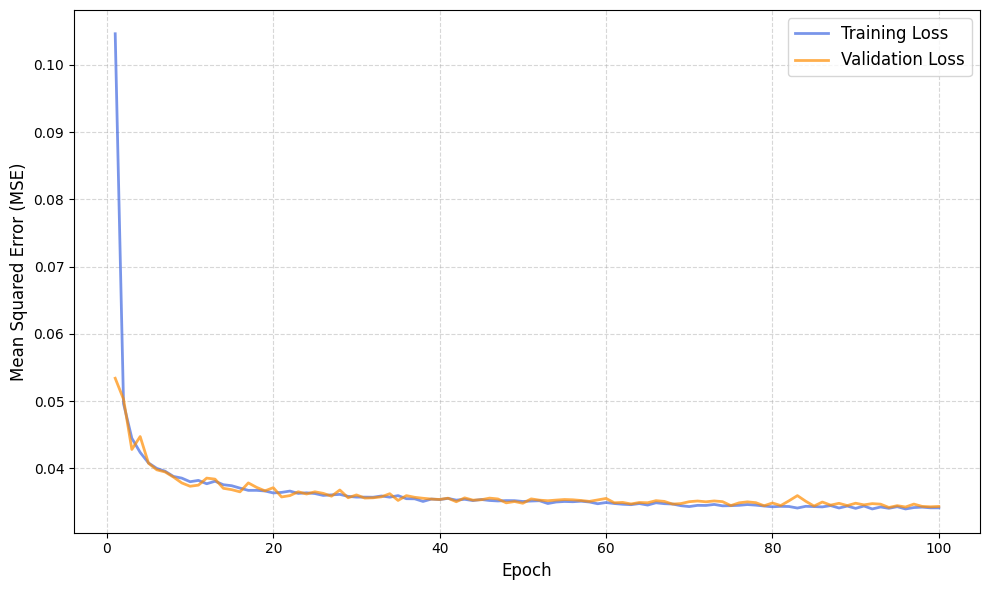

In [ ]:
print("Generating Loss plot...")

plt.figure(figsize=(10, 6))

plt.plot(range(1, N_EPOCHS + 1), train_losses, color='royalblue', linewidth=2, label='Training Loss', alpha = 0.7)
plt.plot(range(1, N_EPOCHS + 1), val_losses, color='darkorange', linewidth=2, label='Validation Loss', alpha = 0.7)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, 'loss_curve.png')
plt.savefig(plot_path, bbox_inches='tight')
print(f"Plot losses saved on Drive: {plot_path}")

plt.show()

# **EXAMPLE OF MNIST TRAINING SAMPLE**

Visualizing an example of the training dataset...


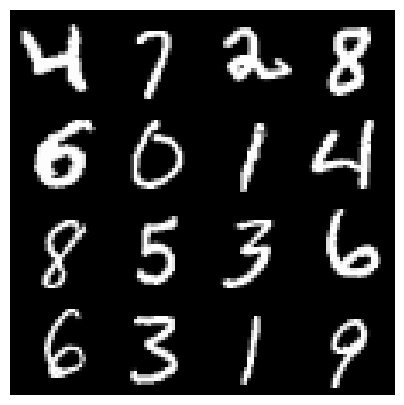

Saved example image on Drive: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/training_examples.png


In [ ]:
import torchvision.utils as vutils
import os
print("Visualizing an example of the training dataset...")

real_batch = next(iter(loader))
real_images = real_batch[0][:16]

grid = vutils.make_grid(real_images, nrow=4, normalize=True, padding=0)

plt.figure(figsize=(5, 5))
plt.axis("off")
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
plt.show()

example_path = os.path.join(OUTPUT_DIR, "training_examples.png")
vutils.save_image(real_images, example_path, nrow=4, normalize=True)
print(f"Saved example image on Drive: {example_path}")


### **VISUALIZATION OF THE REVERSE DENOISING PROCESS**
We want to trace the reverse diffusion trajectory step-by-step. Starting from a tensor of pure isotropic Gaussian noise ($x_T$), we iteratively apply the `p_sample()` method backwards across the 1000 timesteps. At regular intervals, we extract and store two distinct outputs:
1. The **current physical state** of the partially denoised image ($x_{t-1}$).
2. The **model's instantaneous prediction** of the final clean image ($\hat{x}_0$).



In [ ]:
diffusion.eval()
with torch.no_grad():
  img = torch.randn(1,1,28,28).to(device)
  denoise_step = []
  prediction = []
  for timestep in reversed(range(TIME_STEPS)):
    img, x_0 = diffusion.p_sample(img, timestep)

    if timestep % 100 == 0:
      denoise_step.append(img.detach().cpu())
      prediction.append(x_0.detach().cpu())

Plot saved in: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/denoising_process_grid.png


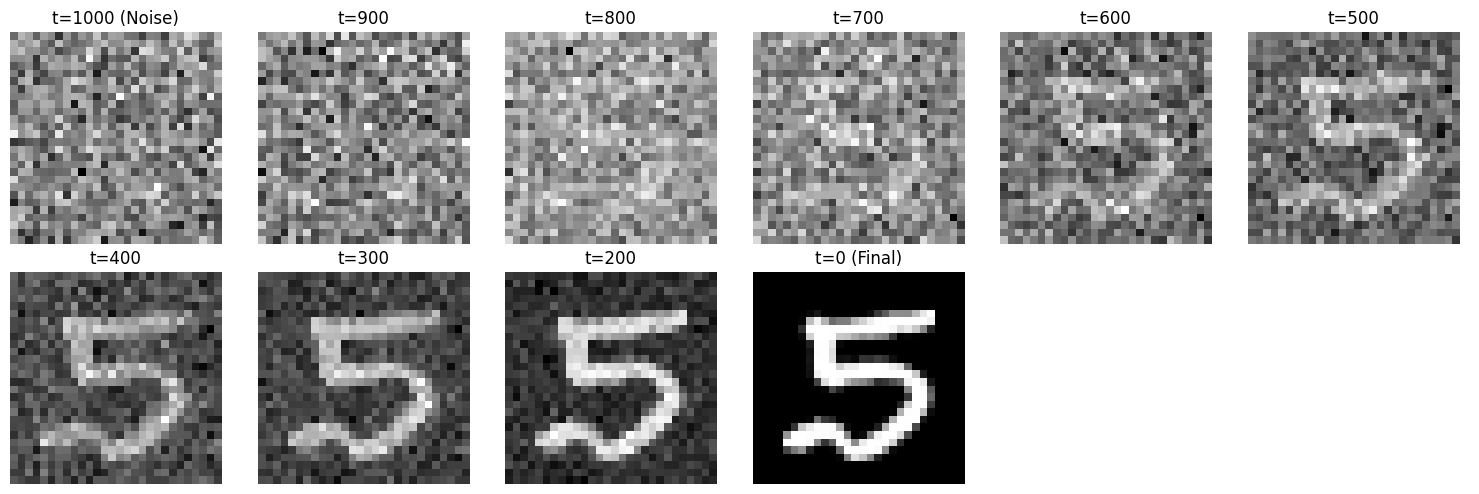

In [ ]:
n_images = len(image_history)
cols = 6
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))
axes = axes.flatten()

for idx in range(len(axes)):
    if idx < n_images:
        img_np = image_history[idx].squeeze().numpy()
        axes[idx].imshow(img_np, cmap='gray')

        if idx == 0:
            axes[idx].set_title("t=1000 (Noise)", fontsize=12)
        elif idx == n_images - 1:
            axes[idx].set_title("t=0 (Final)", fontsize=12)
        else:
            step_val = TIME_STEPS - (idx * 100)
            axes[idx].set_title(f"t={step_val}", fontsize=12)

    axes[idx].axis('off')

plt.tight_layout()

process_plot_path = os.path.join(OUTPUT_DIR, 'denoising_process_grid.png')
plt.savefig(process_plot_path, bbox_inches='tight', dpi=300)
print(f"Plot saved in: {process_plot_path}")

plt.show()

Plot saved in: /content/drive/MyDrive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DIFFUSION MODELS/prediction_process_grid.png


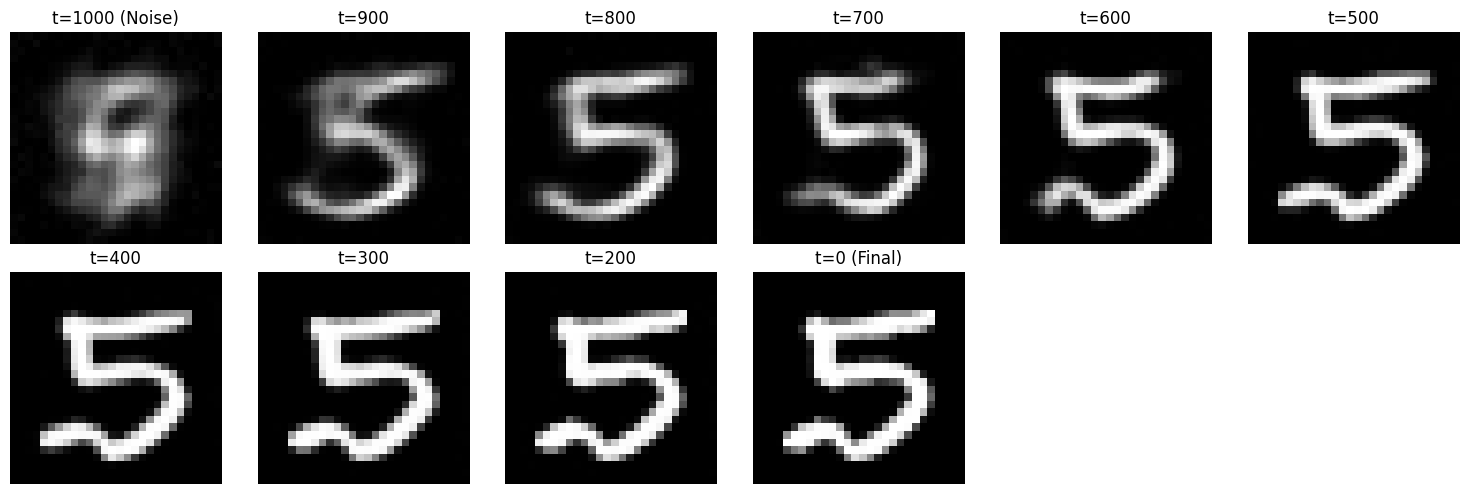

In [ ]:
n_images = len(image_history)
cols = 6
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))
axes = axes.flatten()

for idx in range(len(axes)):
    if idx < n_images:
        img_np = image_prediction[idx].squeeze().numpy()
        axes[idx].imshow(img_np, cmap='gray')

        if idx == 0:
            axes[idx].set_title("t=1000 (Noise)", fontsize=12)
        elif idx == n_images - 1:
            axes[idx].set_title("t=0 (Final)", fontsize=12)
        else:
            step_val = TIME_STEPS - (idx * 100)
            axes[idx].set_title(f"t={step_val}", fontsize=12)

    axes[idx].axis('off')

plt.tight_layout()

process_plot_path = os.path.join(OUTPUT_DIR, 'prediction_process_grid.png')
plt.savefig(process_plot_path, bbox_inches='tight', dpi=300)
print(f"Plot saved in: {process_plot_path}")

plt.show()